In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from skimage.feature import hog

In [4]:
PROJECT_ROOT = Path.cwd().parents[1]

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "metadata.csv"
)

metadata_df = pd.read_csv(
    METADATA_PATH
)

print("Project Root:", PROJECT_ROOT)
print("Samples:", len(metadata_df))

metadata_df.head()

Project Root: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification
Samples: 7934


,file_path,file_name,writer_id,signature_type,is_genuine,processed_path
0,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1.tif,1,genuine,1,data\processed\genuine\1\1.tif
1,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,10.tif,1,genuine,1,data\processed\genuine\1\10.tif
2,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,11.tif,1,genuine,1,data\processed\genuine\1\11.tif
3,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,12.tif,1,genuine,1,data\processed\genuine\1\12.tif
4,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,13.tif,1,genuine,1,data\processed\genuine\1\13.tif


shape :  (128, 256)
Type :  genuine
writer :  34


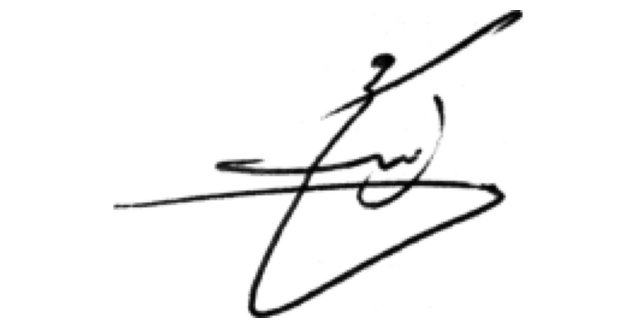

In [5]:
sample_row = metadata_df.sample(1 , random_state=42).iloc[0]

image_path = PROJECT_ROOT / sample_row["processed_path"]

img = cv2.imread(
  str(image_path),
  cv2.IMREAD_GRAYSCALE
)

print("shape : " , img.shape)
print("Type : " , sample_row["signature_type"])
print("writer : " , sample_row["writer_id"])

plt.figure(figsize=(8 , 4))

plt.imshow(
  img, cmap="gray"
)

plt.axis("off")
plt.show()

In [6]:
hog_features , hog_image = hog(
  img,
  orientations = 9,
  pixels_per_cell = (16 , 16),
  cells_per_block = (2,2),
  block_norm="L2-Hys",
  visualize=True,
  feature_vector=True
)

print(
    "HOG Feature Length:",
    len(hog_features)
)

HOG Feature Length: 3780


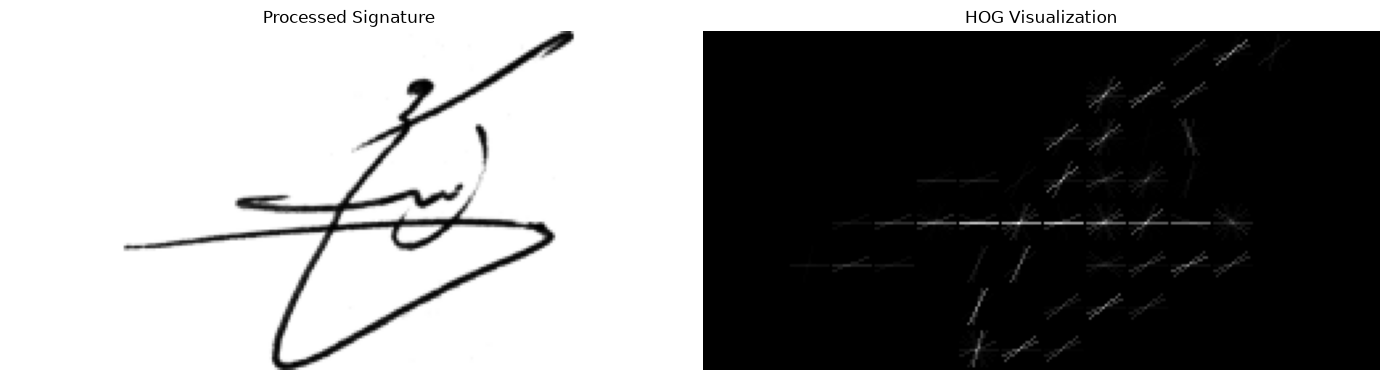

In [7]:
fig , axes = plt.subplots(
  1 , 2 , figsize=(14 , 5)
)

axes[0].imshow(
  img , cmap="gray"
)

axes[0].set_title("Processed Signature")

axes[0].axis("off")

axes[1].imshow(
    hog_image,
    cmap="gray"
)

axes[1].set_title(
    "HOG Visualization"
)

axes[1].axis("off")


plt.tight_layout()
plt.show()

In [8]:
def extract_bsic_feature(image):
  ink_mask = image < 200
  
  ink_density = np.sum(ink_mask) / image.size
  
  horizontal_projection = np.sum(ink_mask , axis=1)
  
  vertical_projection = np.sum(ink_mask , axis= 0)
  
  return (
    ink_density,
    horizontal_projection,
    vertical_projection
  )

In [9]:
ink_density, horizontal_projection, vertical_projection = extract_bsic_feature(
    img
)

print("Ink Density:", ink_density)
print("Horizontal Projection Shape:", horizontal_projection.shape)
print("Vertical Projection Shape:", vertical_projection.shape)

Ink Density: 0.059783935546875
Horizontal Projection Shape: (128,)
Vertical Projection Shape: (256,)


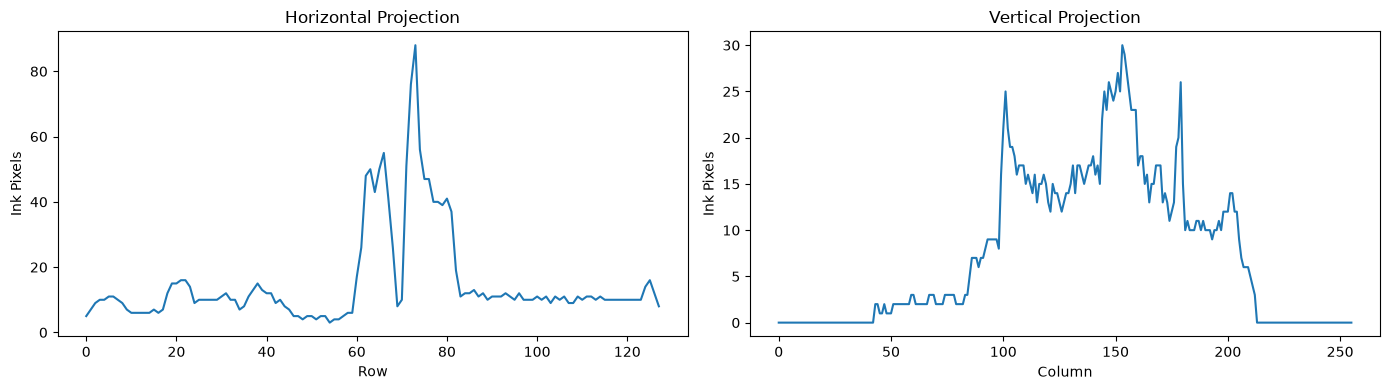

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].plot(
    horizontal_projection
)

axes[0].set_title(
    "Horizontal Projection"
)

axes[0].set_xlabel(
    "Row"
)

axes[0].set_ylabel(
    "Ink Pixels"
)


axes[1].plot(
    vertical_projection
)

axes[1].set_title(
    "Vertical Projection"
)

axes[1].set_xlabel(
    "Column"
)

axes[1].set_ylabel(
    "Ink Pixels"
)

plt.tight_layout()
plt.show()

In [11]:
def extract_hu_moments(image) :
  _ , binary = cv2.threshold(
    image , 0 , 255 , cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
  )
  
  moments = cv2.moments(binary)
  
  hu = cv2.HuMoments(moments).flatten()
  
  hu_log = []
  
  for value in hu :
    if(value == 0):
      hu_log.append(0.0)
    else :
      hu_log.append(-np.sign(value) * np.log10(abs(value)))
      
  return np.array(hu_log)

In [12]:
hu_features = extract_hu_moments(img)

print("Hu Moments : ")
print(hu_features)

print("Feature Count : " , len(hu_features))

Hu Moments : 
[  2.27458855   5.18258228   7.59754564   8.75775778  17.95391419
 -11.9871632   16.93741279]
Feature Count :  7


In [15]:
def extract_contour_features(image) : 
  
  _ , binary = cv2.threshold(
    image , 0 , 255 , cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
  )
  
  contours , _ = cv2.findContours(
    binary , cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_SIMPLE
  )
  
  if(len(contours) == 0) :
    return np.zeros(5)
  
  largest = max(contours , key = cv2.contourArea)
  
  area = cv2.contourArea(largest)
  
  perimeter = cv2.arcLength(largest , True)
  
  x , y , w , h = cv2.boundingRect(largest)
  
  aspect_ratio = (
    w/h
    if h != 0
    else 0
  )
  
  extent = (
    area /(w*h)
    if w*h != 0
    else 0
  ) 
  
  hull = cv2.convexHull(
      largest
  )
  hull_area = cv2.contourArea(
      hull
  )
  solidity = (
      area / hull_area
      if hull_area != 0
      else 0
  )
  
  return np.array([
    area,
    perimeter,
    aspect_ratio,
    extent,
    solidity
  ])

In [16]:
contour_features = extract_contour_features(
    img
)

print(
    "Contour Features:",
    contour_features
)

print(
    "Feature count:",
    len(contour_features)
)

Contour Features: [3.52900000e+03 9.86548333e+02 1.32812500e+00 1.62178309e-01
 3.12549818e-01]
Feature count: 5


In [25]:
def extract_all_features(image):

    # -------------------------
    # 1) HOG
    # -------------------------
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    # -------------------------
    # 2) Basic Features
    # -------------------------
    (
        ink_density,
        horizontal_projection,
        vertical_projection
    ) = extract_bsic_feature(image)

    # -------------------------
    # 3) Hu Moments
    # -------------------------
    hu_features = extract_hu_moments(
        image
    )

    # -------------------------
    # 4) Contour Features
    # -------------------------
    contour_features = extract_contour_features(
        image
    )

    # -------------------------
    # 5) Merge all features
    # -------------------------
    final_features = np.concatenate([
        hog_features,
        np.array([ink_density]),
        horizontal_projection,
        vertical_projection,
        hu_features,
        contour_features
    ])

    return final_features

In [26]:
all_features = extract_all_features(
    img
)

print(
    "Final Feature Vector Shape:",
    all_features.shape
)

print(
    "Total Features:",
    len(all_features)
)

Final Feature Vector Shape: (4177,)
Total Features: 4177


In [27]:
print(
    "NaN count:",
    np.isnan(all_features).sum()
)

print(
    "Inf count:",
    np.isinf(all_features).sum()
)

NaN count: 0
Inf count: 0


In [28]:
from tqdm import tqdm

In [29]:
X_features = []
y_labels = []
writer_ids = []
signature_types = []
failed_features = []

for _, row in tqdm(
    metadata_df.iterrows(),
    total=len(metadata_df)
):

    image_path = (
        PROJECT_ROOT
        / row["processed_path"]
    )

    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        failed_features.append(
            row["processed_path"]
        )
        continue

    try:
        features = extract_all_features(
            img
        )

        X_features.append(
            features
        )

        y_labels.append(
            1
            if row["signature_type"] == "genuine"
            else 0
        )

        writer_ids.append(
            row["writer_id"]
        )

        signature_types.append(
            row["signature_type"]
        )

    except Exception as e:

        failed_features.append({
            "file": row["processed_path"],
            "error": str(e)
        })

100%|██████████| 7934/7934 [02:30<00:00, 52.68it/s]


In [30]:
X = np.array(
    X_features,
    dtype=np.float32
)

y = np.array(
    y_labels,
    dtype=np.int64
)

writer_ids = np.array(
    writer_ids
)

signature_types = np.array(
    signature_types
)

In [31]:
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "Writer IDs shape:",
    writer_ids.shape
)

print(
    "Signature Types shape:",
    signature_types.shape
)

print(
    "Failed:",
    len(failed_features)
)

X shape: (7934, 4177)
y shape: (7934,)
Writer IDs shape: (7934,)
Signature Types shape: (7934,)
Failed: 0


In [32]:
unique_labels, counts = np.unique(
    y,
    return_counts=True
)

for label, count in zip(
    unique_labels,
    counts
):
    print(
        label,
        count
    )

0 4829
1 3105


In [33]:
FEATURE_DIR = (
    PROJECT_ROOT
    / "data"
    / "features"
)

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [34]:
np.save(
    FEATURE_DIR / "X_features.npy",
    X
)

np.save(
    FEATURE_DIR / "y_labels.npy",
    y
)

np.save(
    FEATURE_DIR / "writer_ids.npy",
    writer_ids
)

np.save(
    FEATURE_DIR / "signature_types.npy",
    signature_types
)

In [35]:
print(
    "Feature files saved."
)

Feature files saved.
